<a href="https://colab.research.google.com/github/carlogr-13/Dynamic_Allostery_PLMs/blob/main/topology_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.1. Topología de la red epistática y análisis de centralidad


Procesamiento de resultados de inferencia mutacional de ESM-2 para mapear la arquitectura de red y cuantificar la reorganización. Implementación de la teoría de grafos y métricas de la teoría de la información.

*   Valores centralidad e impacto
*   Mapeo dinámica de red (MST)
*  Sensibilidad epistática distal




## 4.1.1. Identificación de cuellos de botella topológicos

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

drive.mount('/content/drive')
ruta = '/content/drive/MyDrive/TFG_notebooks/Data_PKA/graph_centrality/'
os.chdir(ruta)

df_wt = pd.read_csv('Centrality_PKA_WT.csv')
df_mut = pd.read_csv('Centrality_PKA_I150A.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Calcular P95
p95_wt = np.percentile(df_wt['Betweenness_Centrality'], 95)
p95_mut = np.percentile(df_mut['Betweenness_Centrality'], 95)

# Unir y filtrar (Criterio de Unión)
df_master = pd.merge(df_wt, df_mut, on=['Residue_PDB', 'Amino_Acid'], suffixes=('_WT', '_MUT'))
df_hubs = df_master[(df_master['Betweenness_Centrality_WT'] > p95_wt) |
                    (df_master['Betweenness_Centrality_MUT'] > p95_mut)].copy()

df_hubs['Delta_CB'] = df_hubs['Betweenness_Centrality_MUT'] - df_hubs['Betweenness_Centrality_WT']
df_hubs = df_hubs.sort_values(by='Betweenness_Centrality_WT', ascending=False)

# Limpiar formato para mostrar
df_hubs_show = df_hubs[['Residue_PDB', 'Amino_Acid', 'Betweenness_Centrality_WT', 'Betweenness_Centrality_MUT', 'Delta_CB']].copy()
df_hubs_show.columns = ['Posicion', 'Residuo', 'CB_WT', 'CB_I150A', 'Delta_CB']

# Mostrar tabla interactiva nativa de Colab
df_hubs_show

,Posicion,Residuo,CB_WT,CB_I150A,Delta_CB
0,108,F,0.635000,0.510385,-0.124616
1,119,V,0.579382,0.595979,0.016597
2,190,R,0.534139,0.284458,-0.249681
3,142,H,0.476794,0.682671,0.205877
4,109,S,0.463451,0.286832,-0.176620
5,92,K,0.461779,0.267807,-0.193972
6,193,G,0.352412,0.047347,-0.305066
7,188,A,0.345975,0.052598,-0.293377
8,107,E,0.316214,0.284116,-0.032098
9,244,I,0.315297,0.047275,-0.268023


In [ ]:
# Extraemos solo los que superan el P95 en el WT para la estadística
hubs_wt = df_wt[df_wt['Betweenness_Centrality'] > p95_wt].copy()

print(f"Hay un total de {len(hubs_wt)} residuos que superan el percentil 95 en el estado SILVESTRE (P95 = {p95_wt:.4f}).\n")

min_idx = hubs_wt['Betweenness_Centrality'].idxmin()
max_idx = hubs_wt['Betweenness_Centrality'].idxmax()

res_min = hubs_wt.loc[min_idx, 'Amino_Acid'] + str(hubs_wt.loc[min_idx, 'Residue_PDB'])
res_max = hubs_wt.loc[max_idx, 'Amino_Acid'] + str(hubs_wt.loc[max_idx, 'Residue_PDB'])

print(f"El valor mínimo de este grupo es {round(hubs_wt['Betweenness_Centrality'].min(), 6)} ({res_min})")
print(f"El valor máximo de este grupo es {round(hubs_wt['Betweenness_Centrality'].max(), 6)} ({res_max})\n")

print(f"La media de centralidad (hubs) es {round(hubs_wt['Betweenness_Centrality'].mean(), 6)}")
print(f"La desviación estándar es {round(hubs_wt['Betweenness_Centrality'].std(), 6)}")

Hay un total de 17 residuos que superan el percentil 95 en el estado SILVESTRE (P95 = 0.2619).

El valor mínimo de este grupo es 0.269641 (D301)
El valor máximo de este grupo es 0.635 (F108)

La media de centralidad (hubs) es 0.383717
La desviación estándar es 0.116743


## 4.1.2. Mapeo espacial del flujo de información en el estado basal y mutado

In [ ]:
import pandas as pd

# Cargar los archivos globales del MST
df_wt = pd.read_csv('Edges_PKA_WT.csv')
df_mut = pd.read_csv('Edges_PKA_I150A.csv')

# Función para extraer las aristas y su peso original (JSD)
def extraer_aristas_y_pesos(df):
    diccionario_aristas = {}
    for _, row in df.iterrows():
        # Ordenamos los nodos para que (A,B) sea igual a (B,A)
        nodo_1, nodo_2 = sorted((int(row['Source_PDB']), int(row['Target_PDB'])))
        peso = row['Weight']
        diccionario_aristas[(nodo_1, nodo_2)] = peso
    return diccionario_aristas

dict_wt = extraer_aristas_y_pesos(df_wt)
dict_mut = extraer_aristas_y_pesos(df_mut)

# Creamos conjuntos (Sets) solo con la topología (pares de nodos)
set_wt = set(dict_wt.keys())
set_mut = set(dict_mut.keys())

# Cálculos topológicos
conservadas = set_wt.intersection(set_mut)
aristas_destruidas = set_wt - set_mut
aristas_emergentes = set_mut - set_wt

# Mostrar Resumen Estadístico
print("="*60)
print("RESUMEN TOPOLÓGICO GLOBAL (MST)")
print("="*60)
print(f"Total aristas en WT:      {len(set_wt)}")
print(f"Total aristas en Mutado:  {len(set_mut)}")
print(f"Aristas conservadas:      {len(conservadas)}")
print(f"Porcentaje conservación:  {(len(conservadas) / len(set_wt)) * 100:.2f}%\n")

# Detalle de Aristas Destruidas (Ordenadas por el peso que tenían)
print("="*60)
print(f" ARISTAS DESTRUIDAS (Total: {len(aristas_destruidas)})")
print("   (Rutas que el mutante ha abandonado)")
print("="*60)
# Las ordenamos de mayor a menor peso perdido
destruidas_ordenadas = sorted(aristas_destruidas, key=lambda x: dict_wt[x], reverse=True)
for arista in destruidas_ordenadas:
    peso_perdido = dict_wt[arista]
    print(f"Enlace {arista[0]:>3} - {arista[1]:>3}  |  JSD perdido: {peso_perdido:.4f}")

# Detalle de Aristas Emergentes (Ordenadas por el peso que tienen ahora)
print("\n" + "="*60)
print(f" ARISTAS EMERGENTES DE NOVO (Total: {len(aristas_emergentes)})")
print("   (Rutas nuevas creadas para desviar el flujo)")
print("="*60)
emergentes_ordenadas = sorted(aristas_emergentes, key=lambda x: dict_mut[x], reverse=True)
for arista in emergentes_ordenadas:
    peso_ganado = dict_mut[arista]
    print(f"Enlace {arista[0]:>3} - {arista[1]:>3}  |  JSD ganado:  {peso_ganado:.4f}")

RESUMEN TOPOLÓGICO GLOBAL (MST)
Total aristas en WT:      334
Total aristas en Mutado:  334
Aristas conservadas:      311
Porcentaje conservación:  93.11%

 ARISTAS DESTRUIDAS (Total: 23)
   (Rutas que el mutante ha abandonado)
Enlace 134 - 142  |  JSD perdido: 0.0184
Enlace 240 - 245  |  JSD perdido: 0.0139
Enlace 131 - 135  |  JSD perdido: 0.0105
Enlace 141 - 143  |  JSD perdido: 0.0088
Enlace 113 - 116  |  JSD perdido: 0.0080
Enlace 172 - 175  |  JSD perdido: 0.0071
Enlace  48 -  58  |  JSD perdido: 0.0071
Enlace 172 - 180  |  JSD perdido: 0.0071
Enlace 142 - 226  |  JSD perdido: 0.0063
Enlace 198 - 244  |  JSD perdido: 0.0063
Enlace  66 -  67  |  JSD perdido: 0.0057
Enlace 263 - 270  |  JSD perdido: 0.0052
Enlace 193 - 200  |  JSD perdido: 0.0052
Enlace 231 - 232  |  JSD perdido: 0.0043
Enlace 297 - 300  |  JSD perdido: 0.0039
Enlace 137 - 142  |  JSD perdido: 0.0038
Enlace 133 - 135  |  JSD perdido: 0.0032
Enlace 104 - 121  |  JSD perdido: 0.0029
Enlace 156 - 190  |  JSD perdido: 

In [ ]:
def estandarizar_aristas(df, col_peso):
    df['Nodo_1'] = np.minimum(df['Source_PDB'], df['Target_PDB'])
    df['Nodo_2'] = np.maximum(df['Source_PDB'], df['Target_PDB'])
    return df[['Nodo_1', 'Nodo_2', 'Weight']].rename(columns={'Weight': col_peso})

df_wt_clean = estandarizar_aristas(df_wt, 'JSD_WT')
df_mut_clean = estandarizar_aristas(df_mut, 'JSD_MUT')

# 4. Fusión total de las redes (Outer Join)
# Unimos las tablas. Si una arista no existe en uno de los estados, su peso será 0.0
df_cruce = pd.merge(df_wt_clean, df_mut_clean, on=['Nodo_1', 'Nodo_2'], how='outer').fillna(0.0)

# 5. Calcular la fluctuación de peso (Delta JSD)
# Delta positivo = La arista se vuelve más fuerte en el mutado
# Delta negativo = La arista se debilita en el mutado
df_cruce['Delta_JSD'] = df_cruce['JSD_MUT'] - df_cruce['JSD_WT']

# Calculamos el valor absoluto para ordenar los "Grandes Cambios" sin importar el signo
df_cruce['Impacto_Absoluto'] = df_cruce['Delta_JSD'].abs()

# Ordenamos de mayor a menor impacto
df_cruce = df_cruce.sort_values(by='Impacto_Absoluto', ascending=False).reset_index(drop=True)

# 6. Mostrar los Resultados Top
print("="*75)
print("TOP 20 MAYORES FLUCTUACIONES DE PESO EPISTÁTICO (WT vs I150A)")
print("="*75)
print(f"{'Enlace':<15} | {'JSD WT':<10} | {'JSD MUT':<10} | {'Delta JSD':<10} | {'Tendencia'}")
print("-" * 75)

for i in range(20):
    n1 = int(df_cruce.loc[i, 'Nodo_1'])
    n2 = int(df_cruce.loc[i, 'Nodo_2'])
    wt_val = df_cruce.loc[i, 'JSD_WT']
    mut_val = df_cruce.loc[i, 'JSD_MUT']
    delta = df_cruce.loc[i, 'Delta_JSD']

    enlace_str = f"{n1}-{n2}"

    if delta > 0:
        tendencia = "Aumenta tensión"
    else:
        tendencia = "Pierde fuerza"

    print(f"{enlace_str:<15} | {wt_val:<10.4f} | {mut_val:<10.4f} | {delta:<10.4f} | {tendencia}")

TOP 20 MAYORES FLUCTUACIONES DE PESO EPISTÁTICO (WT vs I150A)
Enlace          | JSD WT     | JSD MUT    | Delta JSD  | Tendencia
---------------------------------------------------------------------------
134-142         | 0.0184     | 0.0000     | -0.0184    | Pierde fuerza
142-144         | 0.0501     | 0.0340     | -0.0161    | Pierde fuerza
134-135         | 0.0000     | 0.0146     | 0.0146     | Aumenta tensión
235-240         | 0.0000     | 0.0140     | 0.0140     | Aumenta tensión
240-245         | 0.0139     | 0.0000     | -0.0139    | Pierde fuerza
131-135         | 0.0105     | 0.0000     | -0.0105    | Pierde fuerza
135-142         | 0.0396     | 0.0291     | -0.0105    | Pierde fuerza
141-142         | 0.0000     | 0.0097     | 0.0097     | Aumenta tensión
48-59           | 0.0000     | 0.0093     | 0.0093     | Aumenta tensión
105-107         | 0.0661     | 0.0571     | -0.0090    | Pierde fuerza
175-177         | 0.2321     | 0.2233     | -0.0088    | Pierde fuerza
141-14

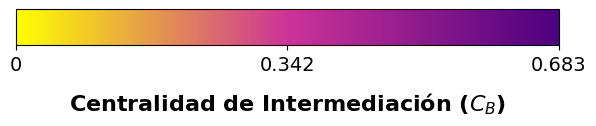

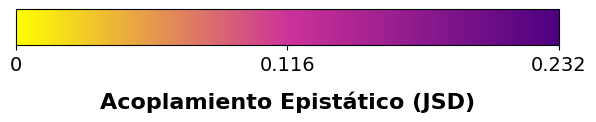

In [ ]:
# Barras gradiente centralidad y acoplamiento epistático
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

colores_pymol = [
    (1.0, 1.0, 0.0),  # norm = 0.0 (Amarillo)
    (0.8, 0.2, 0.6),  # norm = 0.5 (Magenta)
    (0.3, 0.0, 0.5)   # norm = 1.0 (Púrpura)
]

cmap_custom = LinearSegmentedColormap.from_list('PyMOL_Allostery', colores_pymol, N=256)

def generar_barra(titulo, archivo_salida, vmax):
    fig, ax = plt.subplots(figsize=(7, 1.2))
    fig.subplots_adjust(bottom=0.4, top=0.7)

    norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)
    cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap_custom,
                                   norm=norm,
                                   orientation='horizontal')

    cb.set_label(titulo, fontsize=16, fontweight='bold', labelpad=12)
    cb.ax.tick_params(labelsize=14)

    ticks = [0.0, vmax / 2, vmax]
    cb.set_ticks(ticks)

    # LÓGICA RIGUROSA DE FORMATEO
    tick_labels = []
    for t in ticks:
        if t == 0.0:
            tick_labels.append("0") # El cero no lleva decimales
        else:
            tick_labels.append(f"{t:.3f}") # 3 cifras significativas acordes al texto

    cb.set_ticklabels(tick_labels)

    plt.savefig(archivo_salida, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

# Usamos los máximos reales redondeados a 3 decimales
generar_barra('Centralidad de Intermediación ($C_B$)', 'Barra_Centralidad_Definitiva.pdf', vmax=0.683)
generar_barra('Acoplamiento Epistático (JSD)', 'Barra_JSD_Definitiva.pdf', vmax=0.232)